# **Predictive Maintenance using LSTM Autoencoder (Industrial Predictive Intelligence System)**

### **Project Objective**

The objective of this project is to develop a **Predictive Maintenance System** using **LSTM Autoencoders** to detect anomalies in industrial equipment and predict potential failures before they occur.

In industrial environments, unexpected equipment failures can lead to significant downtime and financial loss. This project focuses on leveraging deep learning techniques to monitor system behavior and identify early warning signs of malfunction.

The system is designed to:

- Detect **anomalies in industrial sensor data**  
- Learn **normal operating patterns using LSTM Autoencoders**  
- Identify **potential failures through reconstruction error**  
- Demonstrate the effectiveness of **unsupervised learning for predictive maintenance**  

This project is highly applicable in:
- manufacturing systems  
- industrial IoT (IIoT)  
- equipment monitoring  
- smart factories  

### **Dataset Used**

This project utilizes industrial datasets containing sensor readings from machinery.

### **Dataset Sources**

- Predictive Maintenance Datasets *(e.g., NASA turbofan dataset, industrial sensor datasets, or dataset used in your notebook)*  

### **Dataset Characteristics**

The dataset includes:

- **Sensor data**:
  - temperature  
  - pressure  
  - vibration  
  - other machine signals  

- **Time-series structure**:
  - sequential readings over time  

Key characteristics:
- multivariate time-series data  
- noisy real-world signals  
- imbalance (few anomalies vs many normal instances)  

### **How Dataset is Used in the Project**

The dataset is processed through a predictive maintenance pipeline:

- **Data preprocessing**
  - normalization  
  - noise handling  

- **Sequence preparation**
  - converting sensor data into sequences  

- **Model training**
  - trained on normal operating data  
  - learns reconstruction patterns  

- **Anomaly detection**
  - reconstruction error used to detect anomalies  

The dataset enables the model to learn **normal machine behavior**, which is essential for identifying failures.




### **Import Core Libraries:**

In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Please run: pip install tensorflow")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score, roc_auc_score, roc_curve
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### **Reproducibility Setup:**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Seed fixed at:", SEED)

Seed fixed at: 42


### **Create Project Folders:**

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data_lstm_predictive_maintenance"
ARTIFACT_DIR = BASE_DIR / "artifacts_lstm_predictive_maintenance"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
for folder in [DATA_DIR, ARTIFACT_DIR, MODEL_DIR, PLOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print(DATA_DIR)
print(ARTIFACT_DIR)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Industrial Equipment Failure Detection using LSTM Autoencoder\data_lstm_predictive_maintenance
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Industrial Equipment Failure Detection using LSTM Autoencoder\artifacts_lstm_predictive_maintenance


### **Generate Synthetic Turbofan-Style Dataset:**

In [4]:
def generate_pm_data(n_units=120, cycles=70, n_sensors=8, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    sensor_cols = [f"sensor_{i}" for i in range(1, n_sensors + 1)]

    for unit in range(1, n_units + 1):
        failure_point = rng.integers(int(cycles*0.7), cycles+1)
        op_setting = rng.uniform(0.8, 1.2)
        base = rng.normal(0, 0.4, n_sensors)

        for cycle in range(1, cycles + 1):
            health_ratio = max(0, 1 - cycle / failure_point)
            degrade = (1 - health_ratio)
            sensors = []
            for s in range(n_sensors):
                trend = base[s] + op_setting * 0.1 * np.sin(cycle / 6 + s)
                drift = degrade * rng.uniform(0.5, 1.2) * (1 if s % 2 == 0 else -1)
                noise = rng.normal(0, 0.08)
                sensors.append(trend + drift + noise)

            label = int(cycle >= failure_point - 5)
            row = {"unit_id": unit, "cycle": cycle, "failure_label": label}
            row.update({c: v for c, v in zip(sensor_cols, sensors)})
            rows.append(row)

    return pd.DataFrame(rows), sensor_cols

df, sensor_cols = generate_pm_data(seed=SEED)
print(df.shape)
df.head()

(8400, 11)


,unit_id,cycle,failure_label,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8
0,1,1,0,0.393779,0.537088,-0.752207,-0.617792,-0.014657,-0.289246,-0.006834,-0.314880
1,1,2,0,0.394404,0.481189,-0.701533,-0.633688,0.083971,-0.296692,0.076571,-0.245377
2,1,3,0,0.430479,0.444758,-0.645478,-0.588082,0.069327,-0.280517,0.012430,-0.165987
3,1,4,0,0.515398,0.374889,-0.613363,-0.577622,-0.041579,-0.250224,0.026908,-0.248861
4,1,5,0,0.498179,0.394129,-0.679062,-0.743036,-0.024656,-0.230525,0.106571,-0.268623


### **Initial Inspection:**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8400 entries, 0 to 8399
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   unit_id        8400 non-null   int64  
 1   cycle          8400 non-null   int64  
 2   failure_label  8400 non-null   int64  
 3   sensor_1       8400 non-null   float64
 4   sensor_2       8400 non-null   float64
 5   sensor_3       8400 non-null   float64
 6   sensor_4       8400 non-null   float64
 7   sensor_5       8400 non-null   float64
 8   sensor_6       8400 non-null   float64
 9   sensor_7       8400 non-null   float64
 10  sensor_8       8400 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 722.0 KB


### **Missing Value Check:**

In [6]:
missing_df = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing_df["missing_pct"] = (missing_df["missing_count"] / len(df) * 100).round(3)
missing_df

,missing_count,missing_pct
unit_id,0,0.0
cycle,0,0.0
failure_label,0,0.0
sensor_1,0,0.0
sensor_2,0,0.0
sensor_3,0,0.0
sensor_4,0,0.0
sensor_5,0,0.0
sensor_6,0,0.0
sensor_7,0,0.0


### **Dataset Summary:**

In [7]:
print("Units:", df["unit_id"].nunique())
print("Cycles per unit min/max:", df.groupby("unit_id")["cycle"].max().min(), df.groupby("unit_id")["cycle"].max().max())
print("Failure label rate:", round(float(df["failure_label"].mean()), 4))

Units: 120
Cycles per unit min/max: 70 70
Failure label rate: 0.2402


### **Sensor Summary Statistics:**

In [8]:
df[sensor_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sensor_1,8400.0,0.560568,0.537233,-1.490209,0.211468,0.563303,0.916759,2.263829
sensor_2,8400.0,-0.517460,0.557159,-2.698077,-0.884373,-0.519905,-0.129875,1.130482
sensor_3,8400.0,0.482012,0.479410,-1.081097,0.154248,0.474976,0.807022,2.124091
sensor_4,8400.0,-0.464250,0.482520,-2.114671,-0.789159,-0.454680,-0.120466,1.045484
sensor_5,8400.0,0.532546,0.489839,-0.985049,0.185966,0.523539,0.854367,2.255834
sensor_6,8400.0,-0.475793,0.531525,-2.627075,-0.827841,-0.478695,-0.116096,1.225949
sensor_7,8400.0,0.448225,0.521879,-1.491519,0.084185,0.425873,0.812237,2.175818
sensor_8,8400.0,-0.536408,0.524802,-2.210652,-0.886855,-0.529770,-0.168063,1.330101


### **Plot Example Unit Sensor Trends:**

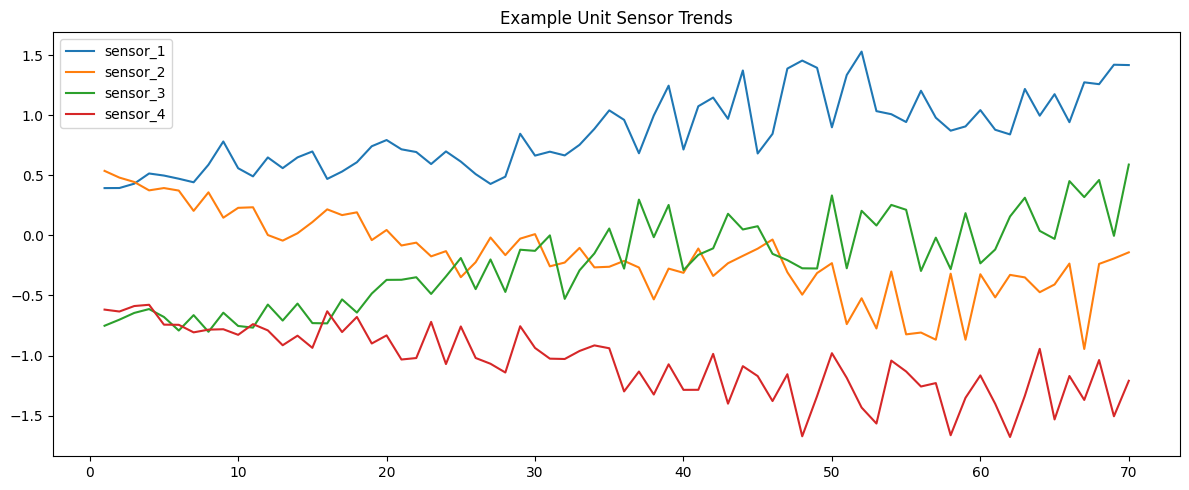

In [9]:
example_unit = 1
subset = df[df["unit_id"] == example_unit]
plt.figure(figsize=(12, 5))
for c in sensor_cols[:4]:
    plt.plot(subset["cycle"], subset[c], label=c)
plt.legend()
plt.title("Example Unit Sensor Trends")
plt.tight_layout()
plt.show()

### **Plot Failure Label Over Cycles:**

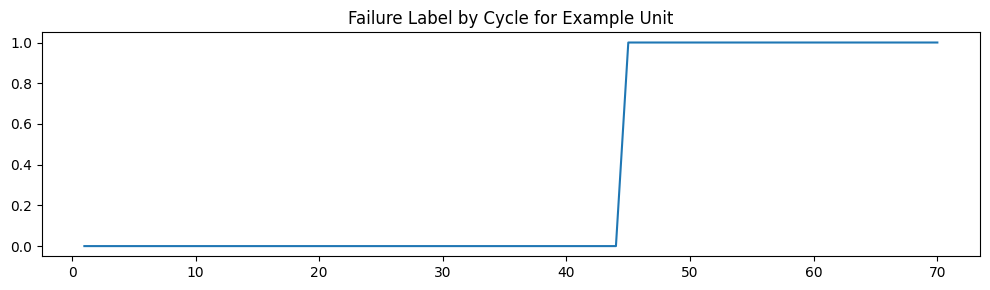

In [10]:
plt.figure(figsize=(10, 3))
plt.plot(subset["cycle"], subset["failure_label"])
plt.title("Failure Label by Cycle for Example Unit")
plt.tight_layout()
plt.show()

### **Average Sensor by Failure State:**

In [11]:
sensor_state_df = df.groupby("failure_label")[sensor_cols].mean().T
sensor_state_df

failure_label,0,1
sensor_1,0.462072,0.872068
sensor_2,-0.397822,-0.895817
sensor_3,0.376803,0.814738
sensor_4,-0.364961,-0.778255
sensor_5,0.405697,0.933710
sensor_6,-0.372775,-0.801593
sensor_7,0.345139,0.774241
sensor_8,-0.412939,-0.926883


### **Plot Mean Sensor Difference by State:**

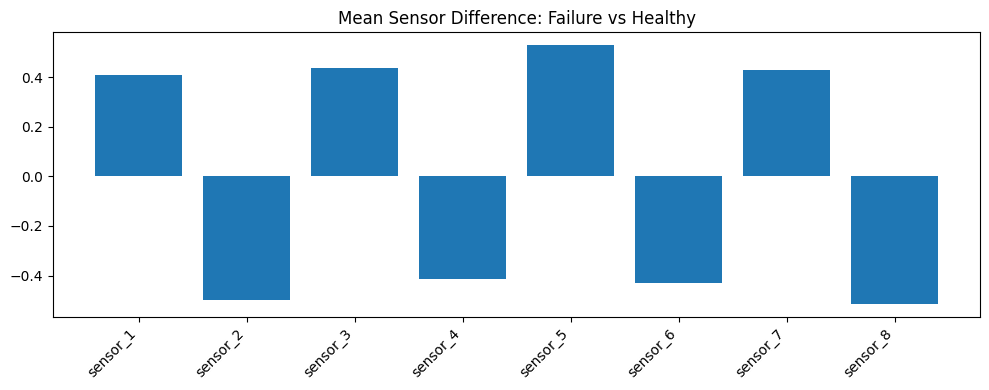

In [12]:
plt.figure(figsize=(10, 4))
diff = sensor_state_df[1] - sensor_state_df[0]
plt.bar(diff.index, diff.values)
plt.xticks(rotation=45, ha="right")
plt.title("Mean Sensor Difference: Failure vs Healthy")
plt.tight_layout()
plt.show()

### **Sort and Split by Unit:**

In [13]:
units = sorted(df["unit_id"].unique())
train_units = units[:int(len(units)*0.7)]
val_units = units[int(len(units)*0.7):int(len(units)*0.85)]
test_units = units[int(len(units)*0.85):]

train_df = df[df["unit_id"].isin(train_units)].copy()
val_df = df[df["unit_id"].isin(val_units)].copy()
test_df = df[df["unit_id"].isin(test_units)].copy()

print(train_df.shape, val_df.shape, test_df.shape)

(5880, 11) (1260, 11) (1260, 11)


### **Scale Sensor Features:**

In [14]:
scaler = StandardScaler()
train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
val_df[sensor_cols] = scaler.transform(val_df[sensor_cols])
test_df[sensor_cols] = scaler.transform(test_df[sensor_cols])
train_df.head()

,unit_id,cycle,failure_label,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8
0,1,1,0,-0.375082,1.915087,-2.517341,-0.226955,-1.051569,0.401881,-0.812163,0.451360
1,1,2,0,-0.373922,1.810728,-2.412904,-0.260043,-0.841886,0.387984,-0.651705,0.587211
2,1,3,0,-0.306942,1.742714,-2.297375,-0.165109,-0.873020,0.418171,-0.775102,0.742386
3,1,4,0,-0.149271,1.612274,-2.231187,-0.143334,-1.108807,0.474706,-0.747249,0.580401
4,1,5,0,-0.181243,1.648194,-2.366590,-0.487668,-1.072827,0.511471,-0.593988,0.541775


### **Sequence Builder:**

In [15]:
def build_windows(df_in, feature_cols, seq_len=20):
    X, y = [], []
    for unit, g in df_in.groupby("unit_id"):
        g = g.sort_values("cycle")
        feat = g[feature_cols].values
        labels = g["failure_label"].values
        for i in range(seq_len, len(g)+1):
            X.append(feat[i-seq_len:i])
            y.append(labels[i-1])
    return np.array(X, dtype="float32"), np.array(y, dtype=int)

### **Build Train/Val/Test Windows:**

In [16]:
SEQ_LEN = 20
X_train_all, y_train_all = build_windows(train_df, sensor_cols, seq_len=SEQ_LEN)
X_val, y_val = build_windows(val_df, sensor_cols, seq_len=SEQ_LEN)
X_test, y_test = build_windows(test_df, sensor_cols, seq_len=SEQ_LEN)

print(X_train_all.shape, y_train_all.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(4284, 20, 8) (4284,)
(918, 20, 8) (918,)
(918, 20, 8) (918,)


### **Train on Healthy Windows Only:**

In [17]:
X_train = X_train_all[y_train_all == 0]
print("Healthy training windows:", X_train.shape)
print("Validation failure rate:", round(float(y_val.mean()), 4))
print("Test failure rate:", round(float(y_test.mean()), 4))

Healthy training windows: (2854, 20, 8)
Validation failure rate: 0.3181
Test failure rate: 0.3224


### **Inspect Window Example:**

In [18]:
pd.DataFrame(X_train[0], columns=sensor_cols).head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8
0,-0.375082,1.915087,-2.517341,-0.226955,-1.051569,0.401881,-0.812163,0.451360
1,-0.373922,1.810728,-2.412904,-0.260043,-0.841886,0.387984,-0.651705,0.587211
2,-0.306942,1.742714,-2.297375,-0.165109,-0.873020,0.418171,-0.775102,0.742386
3,-0.149271,1.612274,-2.231187,-0.143334,-1.108807,0.474706,-0.747249,0.580401
4,-0.181243,1.648194,-2.366590,-0.487668,-1.072827,0.511471,-0.593988,0.541775


### **Mean Signal Profile Across Time:**

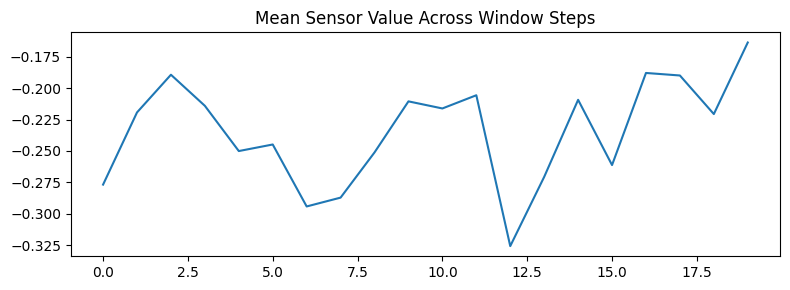

In [19]:
mean_profile = X_train[0].mean(axis=1)
plt.figure(figsize=(8, 3))
plt.plot(mean_profile)
plt.title("Mean Sensor Value Across Window Steps")
plt.tight_layout()
plt.show()

### **Build LSTM Autoencoder:**

In [20]:
def build_lstm_autoencoder(seq_len, n_features):
    inputs = tf.keras.Input(shape=(seq_len, n_features))
    x = tf.keras.layers.LSTM(64, return_sequences=True)(inputs)
    x = tf.keras.layers.LSTM(32, return_sequences=False)(x)
    x = tf.keras.layers.RepeatVector(seq_len)(x)
    x = tf.keras.layers.LSTM(32, return_sequences=True)(x)
    x = tf.keras.layers.LSTM(64, return_sequences=True)(x)
    outputs = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_features))(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="mse", metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")])
    return model

### **Instantiate Autoencoder:**

In [21]:
autoencoder = build_lstm_autoencoder(seq_len=X_train.shape[1], n_features=X_train.shape[2])
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 20, 8)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 20, 64)              │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 20, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 20, 32)              │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 20, 64)              │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 20, 8)               │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,776 (253.03 KB)

 Trainable params: 64,776 (253.03 KB)

 Non-trainable params: 0 (0.00 B)

### **Training Callbacks:**

In [22]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

### **Prepare Healthy Validation Windows:**

In [23]:
X_val_healthy = X_val[y_val == 0]
print(X_val_healthy.shape)

(626, 20, 8)


### **Train Autoencoder:**

In [24]:
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val_healthy, X_val_healthy),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.5289 - mae: 0.5669 - val_loss: 0.3969 - val_mae: 0.4879 - learning_rate: 0.0010
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2481 - mae: 0.3779 - val_loss: 0.2606 - val_mae: 0.3953 - learning_rate: 0.0010
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1595 - mae: 0.3004 - val_loss: 0.2153 - val_mae: 0.3609 - learning_rate: 0.0010
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1273 - mae: 0.2708 - val_loss: 0.1963 - val_mae: 0.3457 - learning_rate: 0.0010
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1106 - mae: 0.2551 - val_loss: 0.1792 - val_mae: 0.3310 - learning_rate: 0.0010
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1001 - mae: 0.2448 - val_loss: 0.1686 - val_mae: 0.3220 - learning_rate: 0.0010
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0927 - mae: 0.2372 - val_loss: 0.1594 - val_mae: 0.3143 - learning_rate: 0.0010
Epoch 8/20
45

### **Plot Training vs Validation Loss:**

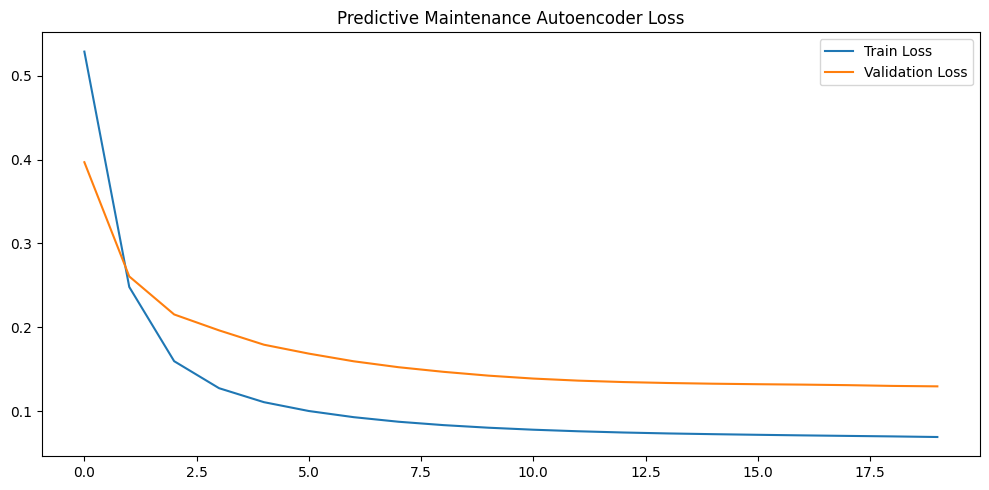

In [25]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Predictive Maintenance Autoencoder Loss")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Training vs Validation MAE:**

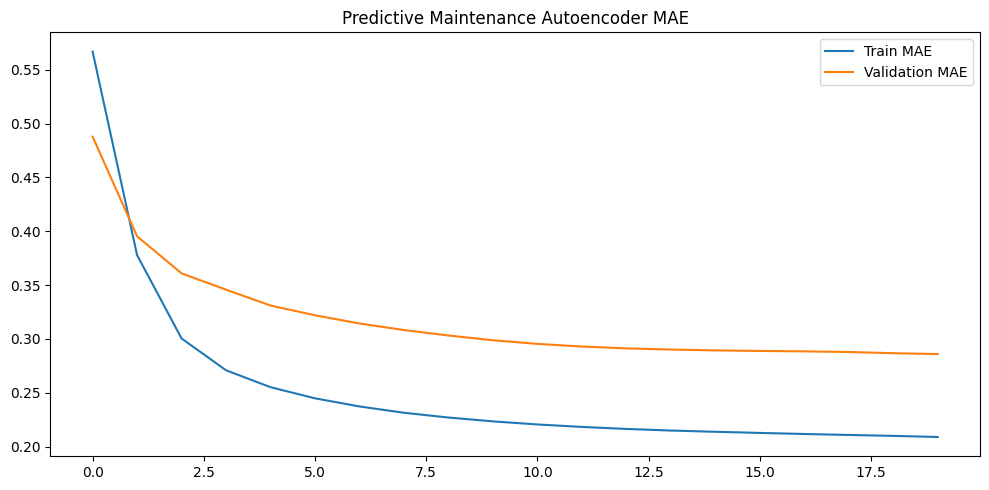

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["mae"], label="Train MAE")
plt.plot(history_df["val_mae"], label="Validation MAE")
plt.title("Predictive Maintenance Autoencoder MAE")
plt.legend()
plt.tight_layout()
plt.show()

### **Reconstruct Train/Val/Test Windows:**

In [27]:
train_recon = autoencoder.predict(X_train, verbose=0)
val_recon = autoencoder.predict(X_val, verbose=0)
test_recon = autoencoder.predict(X_test, verbose=0)

train_errors = np.mean(np.abs(X_train - train_recon), axis=(1,2))
val_errors = np.mean(np.abs(X_val - val_recon), axis=(1,2))
test_errors = np.mean(np.abs(X_test - test_recon), axis=(1,2))
print(train_recon.shape, val_recon.shape, test_recon.shape)

(2854, 20, 8) (918, 20, 8) (918, 20, 8)


### **Training Error Summary:**

In [28]:
pd.Series(train_errors).describe()

count    2854.000000
mean        0.207906
std         0.041031
min         0.131596
25%         0.173530
50%         0.203013
75%         0.238719
max         0.338667
dtype: float64

### **Plot Training Error Distribution:**

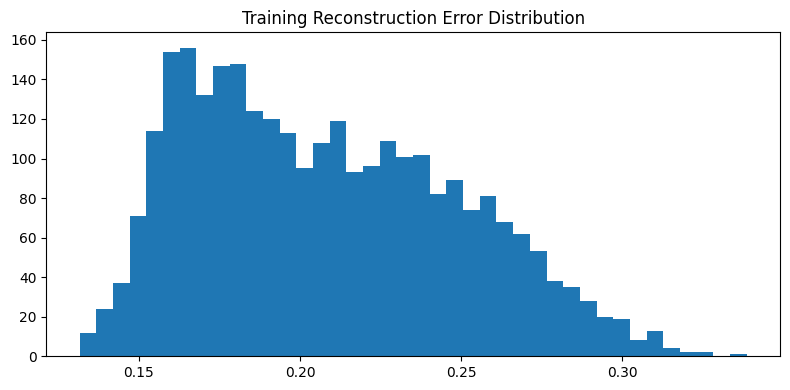

In [29]:
plt.figure(figsize=(8, 4))
plt.hist(train_errors, bins=40)
plt.title("Training Reconstruction Error Distribution")
plt.tight_layout()
plt.show()

### **Set Failure Threshold:**

In [30]:
threshold = float(np.mean(train_errors) + 3 * np.std(train_errors))
print("Threshold:", threshold)

Threshold: 0.3309761472046375


### **Plot Training Error Threshold:**

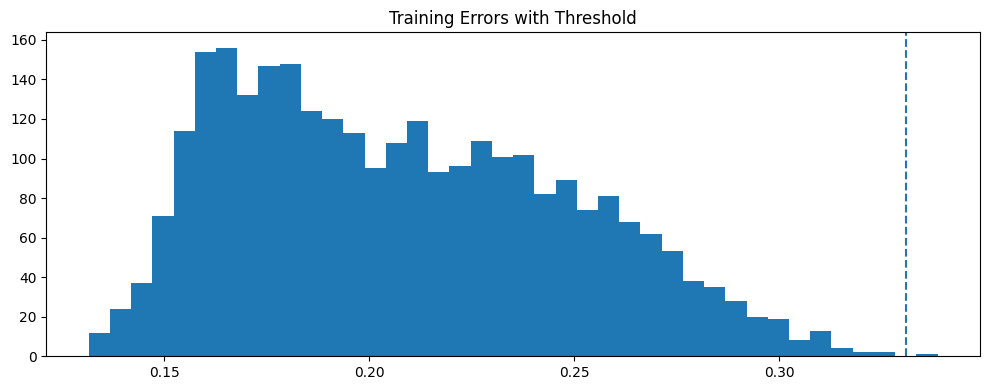

In [31]:
plt.figure(figsize=(10, 4))
plt.hist(train_errors, bins=40)
plt.axvline(threshold, linestyle="--")
plt.title("Training Errors with Threshold")
plt.tight_layout()
plt.show()

### **Build Validation Predictions:**

In [32]:
val_pred = (val_errors >= threshold).astype(int)
val_acc = accuracy_score(y_val, val_pred)
val_auc = roc_auc_score(y_val, val_errors)
print(val_acc, val_auc)

0.840958605664488 0.9327760514683355


### **Build Test Predictions:**

In [33]:
test_pred = (test_errors >= threshold).astype(int)
test_acc = accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_errors)
print(test_acc, test_auc)

0.7984749455337691 0.8867048318414877


### **Classification Report:**

In [34]:
print(classification_report(y_test, test_pred, target_names=["healthy", "failure"], digits=4))

              precision    recall  f1-score   support

     healthy     0.9194    0.7701    0.8381       622
     failure     0.6398    0.8581    0.7330       296

    accuracy                         0.7985       918
   macro avg     0.7796    0.8141    0.7856       918
weighted avg     0.8292    0.7985    0.8043       918



### **Precision / Recall / F1 Table:**

In [35]:
precision, recall, f1, support = precision_recall_fscore_support(y_test, test_pred)
metrics_df = pd.DataFrame({
    "class": ["healthy", "failure"],
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support
})
metrics_df

,class,precision,recall,f1_score,support
0,healthy,0.919386,0.770096,0.838145,622
1,failure,0.639798,0.858108,0.733045,296


### **Confusion Matrix:**

In [36]:
cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(cm, index=["healthy", "failure"], columns=["healthy", "failure"])
cm_df

,healthy,failure
healthy,479,143
failure,42,254


### **Plot Confusion Matrix:**

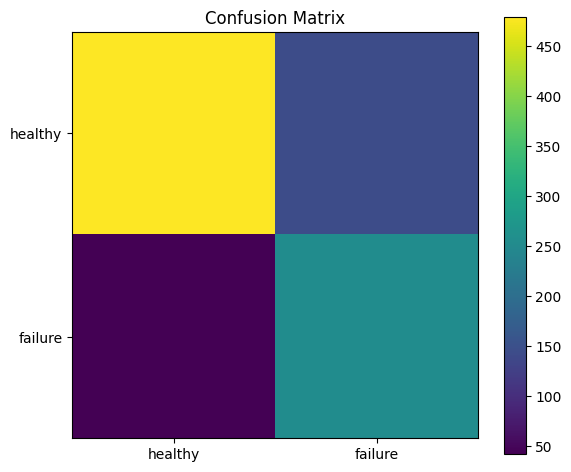

In [37]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["healthy", "failure"])
plt.yticks([0,1], ["healthy", "failure"])
plt.tight_layout()
plt.show()

### **ROC Curve:**

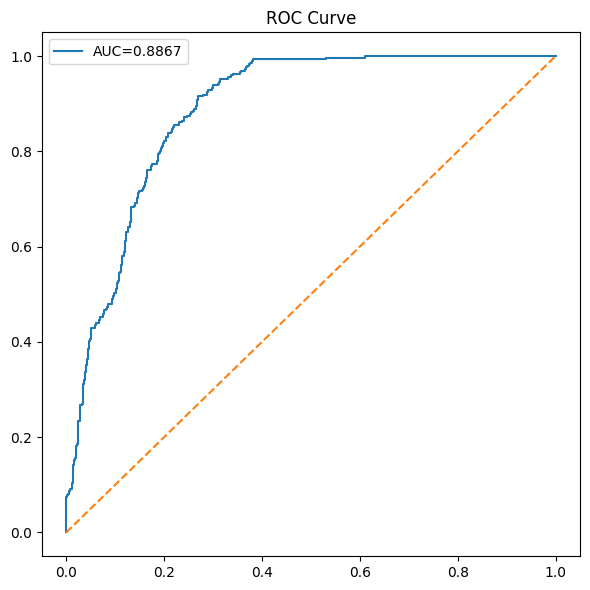

In [38]:
fpr, tpr, _ = roc_curve(y_test, test_errors)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC={test_auc:.4f}")
plt.plot([0,1],[0,1],"--")
plt.legend()
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

### **Error Distribution by Class:**

In [39]:
error_df = pd.DataFrame({"label": y_test, "reconstruction_error": test_errors})
error_df.groupby("label")["reconstruction_error"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,622.0,0.290602,0.074329,0.165849,0.239543,0.274868,0.325688,0.631972
1,296.0,0.429347,0.114372,0.260625,0.353885,0.399174,0.478192,0.856873


### **Plot Error Distribution by Class:**

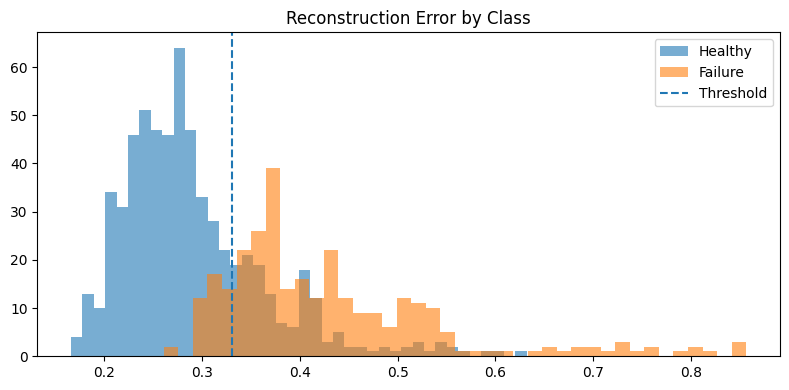

In [40]:
plt.figure(figsize=(8, 4))
plt.hist(test_errors[y_test == 0], bins=40, alpha=0.6, label="Healthy")
plt.hist(test_errors[y_test == 1], bins=40, alpha=0.6, label="Failure")
plt.axvline(threshold, linestyle="--", label="Threshold")
plt.legend()
plt.title("Reconstruction Error by Class")
plt.tight_layout()
plt.show()

### **Healthy Window Reconstruction Examples:**

In [41]:
healthy_idx = np.where(y_test == 0)[0]
best_healthy = healthy_idx[np.argsort(test_errors[healthy_idx])[:3]]
best_healthy

array([52, 51, 53], dtype=int64)

### **Visualize Healthy Reconstructions:**

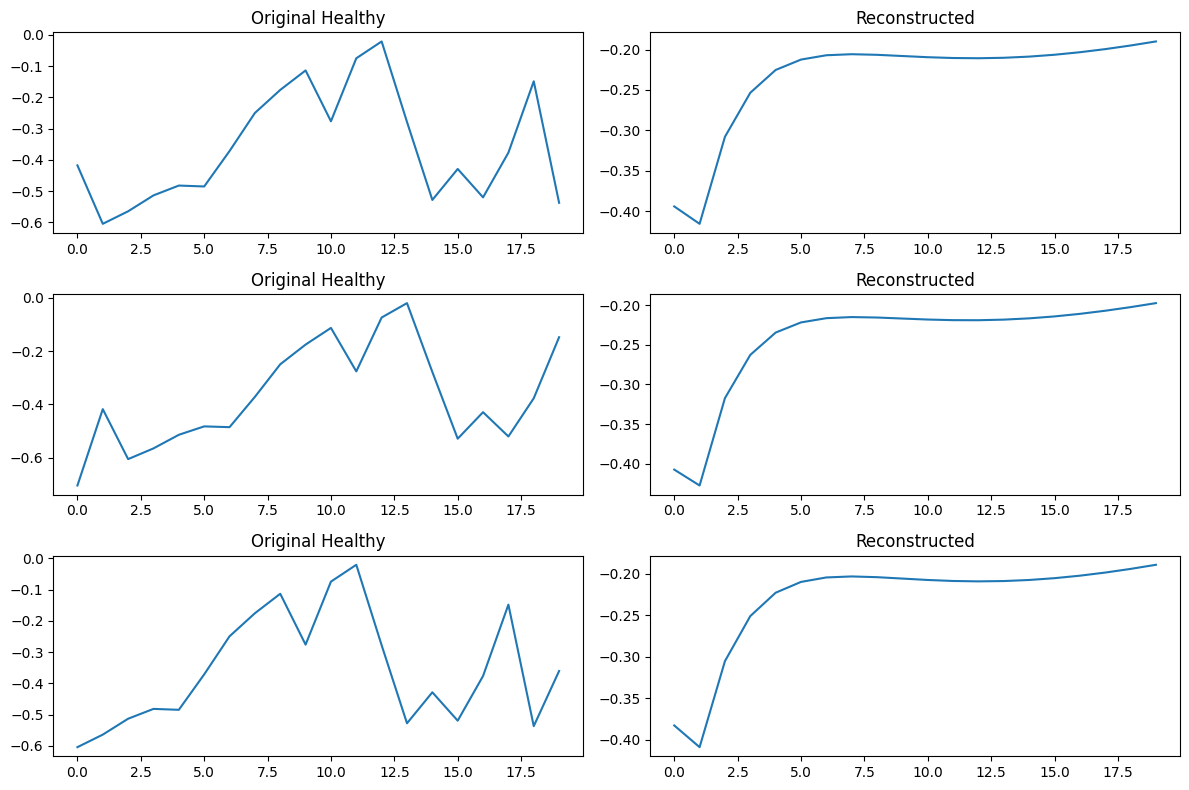

In [42]:
plt.figure(figsize=(12, 8))
for i, idx in enumerate(best_healthy):
    ax = plt.subplot(3, 2, 2*i+1)
    plt.plot(X_test[idx][:,0])
    ax.set_title("Original Healthy")
    ax = plt.subplot(3, 2, 2*i+2)
    plt.plot(test_recon[idx][:,0])
    ax.set_title("Reconstructed")
plt.tight_layout()
plt.show()

### **Failure Window Reconstruction Examples:**

In [43]:
failure_idx = np.where(y_test == 1)[0]
worst_failure = failure_idx[np.argsort(test_errors[failure_idx])[-3:]]
worst_failure

array([762, 763, 764], dtype=int64)

### **Visualize Failure Reconstructions:**

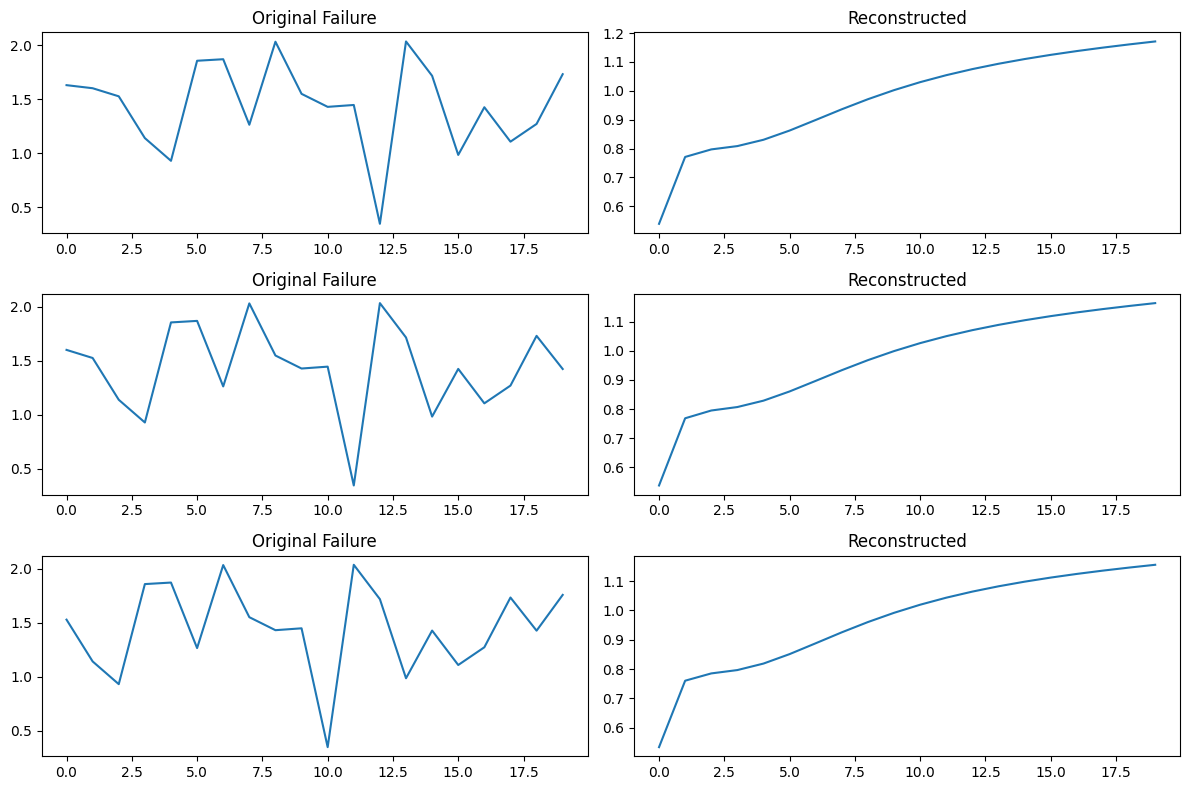

In [44]:
plt.figure(figsize=(12, 8))
for i, idx in enumerate(worst_failure):
    ax = plt.subplot(3, 2, 2*i+1)
    plt.plot(X_test[idx][:,0])
    ax.set_title("Original Failure")
    ax = plt.subplot(3, 2, 2*i+2)
    plt.plot(test_recon[idx][:,0])
    ax.set_title("Reconstructed")
plt.tight_layout()
plt.show()

### **Threshold Sensitivity Sweep:**

In [45]:
thresholds = np.linspace(np.percentile(train_errors, 90), np.percentile(train_errors, 99.5), 15)
rows = []
for thr in thresholds:
    pred_thr = (test_errors >= thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_test, pred_thr, average="binary", zero_division=0)
    rows.append({"threshold": thr, "precision": p, "recall": r, "f1": f})
threshold_df = pd.DataFrame(rows)
threshold_df.head()

,threshold,precision,recall,f1
0,0.266133,0.451761,0.996622,0.621707
1,0.269292,0.459502,0.996622,0.628998
2,0.272451,0.471246,0.996622,0.639913
3,0.275610,0.490000,0.993243,0.656250
4,0.278769,0.506897,0.993243,0.671233


### **Plot Threshold Sensitivity:**

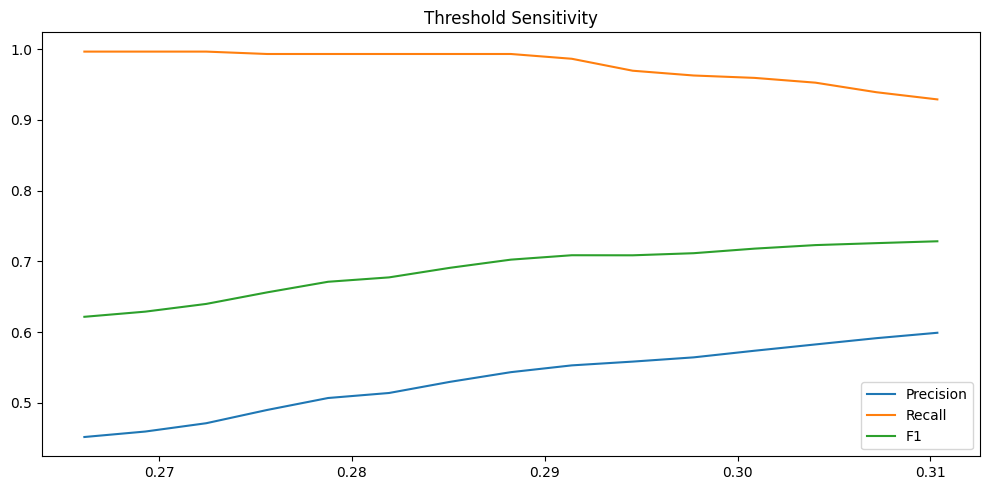

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.legend()
plt.title("Threshold Sensitivity")
plt.tight_layout()
plt.show()

### **Sample Detection Table:**

In [47]:
sample_df = pd.DataFrame({
    "true_label": y_test[:20],
    "predicted_label": test_pred[:20],
    "reconstruction_error": test_errors[:20]
})
sample_df

,true_label,predicted_label,reconstruction_error
0,0,1,0.391840
1,0,1,0.389591
2,0,1,0.378538
3,0,1,0.377038
4,0,1,0.376238
5,0,1,0.377080
6,0,1,0.381956
7,0,1,0.391004
8,0,1,0.393789
9,0,1,0.404281


### **Save Model Artifacts:**

In [48]:
model_path = MODEL_DIR / "lstm_autoencoder_predictive_maintenance.keras"
meta_path = MODEL_DIR / "pm_meta.json"

autoencoder.save(model_path)
meta = {
    "seq_len": int(X_train.shape[1]),
    "n_features": int(X_train.shape[2]),
    "threshold": threshold,
    "sensor_cols": sensor_cols,
    "seed": SEED
}
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=4)

print(model_path)
print(meta_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Industrial Equipment Failure Detection using LSTM Autoencoder\artifacts_lstm_predictive_maintenance\models\lstm_autoencoder_predictive_maintenance.keras
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Industrial Equipment Failure Detection using LSTM Autoencoder\artifacts_lstm_predictive_maintenance\models\pm_meta.json


### **Reload Model for Sanity Check:**

In [49]:
reloaded_model = tf.keras.models.load_model(model_path)
sanity_pred = reloaded_model.predict(X_test[:2], verbose=0)
sanity_pred.shape

(2, 20, 8)

### **Final Metrics Summary Table:**

In [50]:
summary_table = pd.DataFrame({
    "Metric": ["Validation Accuracy", "Validation AUC", "Test Accuracy", "Test AUC", "Threshold"],
    "Value": [val_acc, val_auc, test_acc, test_auc, threshold]
})
summary_table

,Metric,Value
0,Validation Accuracy,0.840959
1,Validation AUC,0.932776
2,Test Accuracy,0.798475
3,Test AUC,0.886705
4,Threshold,0.330976


### **Project Summary**

This project presents a complete implementation of a **Predictive Maintenance System using LSTM Autoencoders**, focusing on detecting anomalies in industrial systems.

The workflow begins with preprocessing sensor data, including normalization and sequence preparation.

The core of the system is an **LSTM Autoencoder Model**, which consists of:

### **1. Encoder**

- Compresses input sensor sequences  
- Learns latent representation of normal behavior  

### **2. Latent Space**

- Captures essential system patterns  

### **3. Decoder**

- Reconstructs input sequences  

### **4. Anomaly Detection Mechanism**

- Computes reconstruction error  
- High error indicates potential fault  

The model learns:
- normal operating conditions  
- temporal dependencies in sensor data  
- deviations indicating failures  

A key strength of this project is:

- **Unsupervised anomaly detection**
  - no need for labeled failures  

- **Real-time applicability**
  - suitable for monitoring systems  

Evaluation is performed using:

- reconstruction error thresholds  
- precision, recall, F1-score  

The system can be used in real-world applications to:

- predict equipment failures  
- reduce downtime  
- optimize maintenance schedules  

Overall, this project demonstrates advanced AI capabilities and showcases the ability to build **industrial predictive maintenance systems using deep learning**.

### **Key Highlights**

- Built a **Predictive Maintenance system using LSTM Autoencoders**, targeting industrial AI applications.

- Addressed critical problem:
  - predicting equipment failures  

- Utilized dataset with:
  - multivariate industrial sensor data  

- Implemented a complete **data preprocessing pipeline**, including:
  - normalization  
  - sequence preparation  

- Leveraged **LSTM Autoencoders**, enabling:
  - unsupervised anomaly detection  

- Designed a **reconstruction-based detection system**, enabling:
  - identification of abnormal machine behavior  

- Applied **temporal modeling**, enabling:
  - capturing sequential dependencies  

- Developed a **predictive system**, capable of:
  - detecting anomalies  
  - predicting failures  

- Evaluated model performance using:
  - precision, recall, F1-score  

- Enabled **real-world applications**, including:
  - manufacturing systems  
  - smart factories  
  - industrial IoT  

- Designed for **deployment scenarios**, including:
  - real-time monitoring systems  
  - predictive maintenance platforms  

- Demonstrates strong expertise in:
  - **time-series analysis**  
  - **unsupervised learning**  
  - **industrial AI systems**